<a href="https://colab.research.google.com/github/Maxiwel-Cloud/ESG-Analytics-S-P500/blob/main/S%26P_500_Firms_ESG_Sustainability_Reports.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection

Load Dataset

In [2]:
import pandas as pd
df = pd.read_csv('preprocessed_content.csv')
df.head()

,Unnamed: 0,filename,ticker,year,preprocessed_content,ner_entities,e_score,s_score,g_score,total_score
0,0,ASX_BSX_2020.pdf,BSX,2020,style guide colour colour use imagecolour prof...,"['bk%', 'rgb', 'un', 'el ectric mine consortiu...",3.16,18.00,11.83,32.98
1,1,ASX_BSX_2022.pdf,BSX,2022,sustainability report look mining green office...,"['murray street', 'west perth', 'west perth', ...",2.83,12.86,10.32,26.02
2,2,ASX_EXR_2022.pdf,EXR,2022,report environment social governance esg basel...,"['september', 'mongolia', 'australia', 'austra...",3.81,4.28,5.86,13.94
3,3,LSE_ADM_2019.pdf,ADM,2019,corporate social responsibilty report introduc...,"['david stevens', 'csr board', 'just over yea...",16.38,14.20,5.90,36.36
4,4,LSE_ADM_2020.pdf,ADM,2020,sustainability admiral commit maintain respons...,"['year', 'health & wellbeing', 'a -month', 'on...",15.89,13.51,5.38,34.78


In [4]:
df.columns

Index(['Unnamed: 0', 'filename', 'ticker', 'year', 'preprocessed_content',
       'ner_entities', 'e_score', 's_score', 'g_score', 'total_score'],
      dtype='object')

In [5]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,filename,ticker,year,preprocessed_content,ner_entities,e_score,s_score,g_score,total_score
0,ASX_BSX_2020.pdf,BSX,2020,style guide colour colour use imagecolour prof...,"['bk%', 'rgb', 'un', 'el ectric mine consortiu...",3.16,18.00,11.83,32.98
1,ASX_BSX_2022.pdf,BSX,2022,sustainability report look mining green office...,"['murray street', 'west perth', 'west perth', ...",2.83,12.86,10.32,26.02
2,ASX_EXR_2022.pdf,EXR,2022,report environment social governance esg basel...,"['september', 'mongolia', 'australia', 'austra...",3.81,4.28,5.86,13.94
3,LSE_ADM_2019.pdf,ADM,2019,corporate social responsibilty report introduc...,"['david stevens', 'csr board', 'just over yea...",16.38,14.20,5.90,36.36
4,LSE_ADM_2020.pdf,ADM,2020,sustainability admiral commit maintain respons...,"['year', 'health & wellbeing', 'a -month', 'on...",15.89,13.51,5.38,34.78


In [6]:
print("Total rows:", df.shape[0])
print("Unique companies:", df['ticker'].nunique())
print("Years available:", df['year'].unique())

Total rows: 866
Unique companies: 263
Years available: [2020 2022 2019 2021 2023 2018 2017 2016 2014 2015]


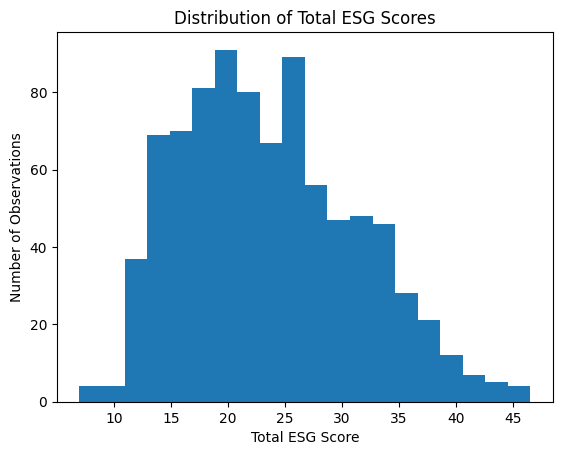

In [8]:
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df['total_score'], bins=20)
plt.xlabel('Total ESG Score')
plt.ylabel('Number of Observations')
plt.title('Distribution of Total ESG Scores')
plt.show()

In [9]:
print("Average E:", df['e_score'].mean())
print("Average S:", df['s_score'].mean())
print("Average G:", df['g_score'].mean())
print("Average Total:", df['total_score'].mean())

Average E: 5.904133949191685
Average S: 10.272228637413395
Average G: 7.423741339491918
Average Total: 23.612240184757507


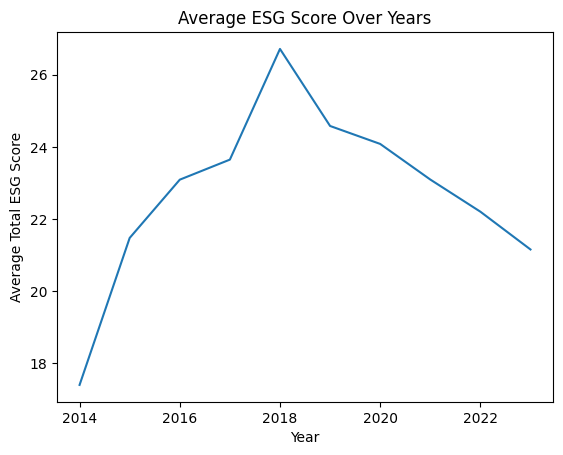

In [10]:
year_avg = df.groupby('year')['total_score'].mean()

year_avg.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Average Total ESG Score')
plt.title('Average ESG Score Over Years')
plt.show()

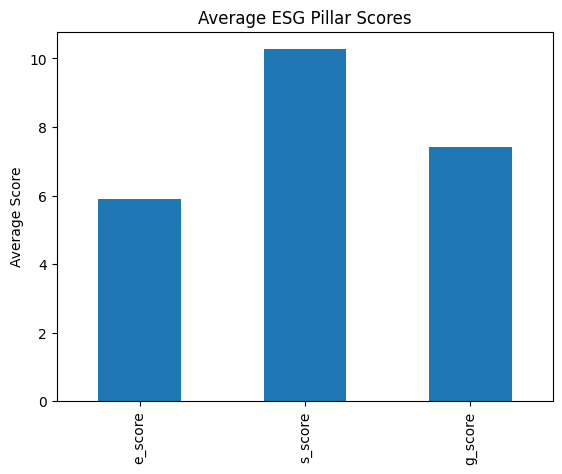

In [11]:
pillar_avg = df[['e_score', 's_score', 'g_score']].mean()

pillar_avg.plot(kind='bar')
plt.ylabel('Average Score')
plt.title('Average ESG Pillar Scores')
plt.show()

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [13]:
X = df[['e_score', 's_score', 'g_score']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['ESG_cluster'] = kmeans.fit_predict(X_scaled)

df['ESG_cluster'].value_counts()

,count
ESG_cluster,
2,387
0,276
1,203


In [15]:

cluster_map = {
    0: "Low ESG",
    1: "Medium ESG",
    2: "High ESG"
}

df['ESG_category'] = df['ESG_cluster'].map(cluster_map)

In [16]:
df.groupby('ESG_cluster')[['e_score','s_score','g_score','total_score']].mean()

,e_score,s_score,g_score,total_score
ESG_cluster,,,,
0,2.833370,13.777355,10.109891,26.731522
1,14.686847,10.306946,6.720788,31.731921
2,3.487183,7.754238,5.876770,17.128475


In [17]:
df['custom_esg_score'] = (
    0.4 * df['e_score'] +
    0.3 * df['s_score'] +
    0.3 * df['g_score']
)

df[['ticker','year','custom_esg_score']].head()

,ticker,year,custom_esg_score
0,BSX,2020,10.213
1,BSX,2022,8.086
2,EXR,2022,4.566
3,ADM,2019,12.582
4,ADM,2020,12.023


In [19]:
df['custom_rank'] = df.groupby('year')['custom_esg_score'] \
                       .rank(ascending=False, method='dense')

df[['ticker','year','custom_esg_score','custom_rank']].head(10)

,ticker,year,custom_esg_score,custom_rank
0,BSX,2020,10.213,48.0
1,BSX,2022,8.086,55.0
2,EXR,2022,4.566,131.0
3,ADM,2019,12.582,15.0
4,ADM,2020,12.023,16.0
5,ADM,2021,11.866,17.0
6,BBY,2020,3.784,215.0
7,AAPL,2019,7.435,94.0
8,AAPL,2021,5.037,186.0
9,AAPL,2022,5.003,119.0


In [20]:
df[['total_score','custom_esg_score']].corr()

,total_score,custom_esg_score
total_score,1.000000,0.987737
custom_esg_score,0.987737,1.000000


In [21]:
latest_year = df['year'].max()

top10 = df[df['year'] == latest_year] \
        .sort_values(by='custom_esg_score', ascending=False) \
        .head(10)

top10[['ticker','custom_esg_score','e_score','s_score','g_score']]

,ticker,custom_esg_score,e_score,s_score,g_score
633,MMM,12.927,17.22,13.59,6.54
220,QRVO,9.912,12.72,8.50,7.58
300,AEP,9.108,12.66,8.10,5.38
474,EMN,8.726,12.41,5.64,6.90
559,ITW,8.290,7.00,11.78,6.52
74,CSGP,7.845,5.16,11.23,8.04
709,RJF,7.823,1.76,10.80,12.93
141,ISRG,6.686,3.65,9.58,7.84
318,AMP,6.662,2.33,7.52,11.58
496,FDX,6.473,5.66,8.42,5.61


In [22]:
corr_matrix = df[['e_score','s_score','g_score','total_score']].corr()

corr_matrix

,e_score,s_score,g_score,total_score
e_score,1.000000,-0.029369,-0.158549,0.682293
s_score,-0.029369,1.000000,0.412967,0.645694
g_score,-0.158549,0.412967,1.000000,0.433859
total_score,0.682293,0.645694,0.433859,1.000000


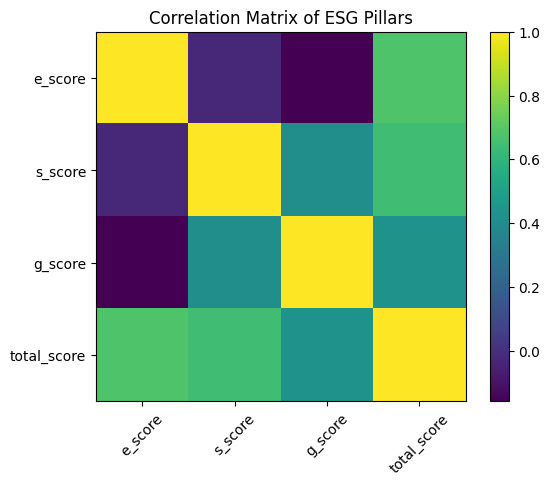

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of ESG Pillars")
plt.show()

In [25]:
df = df.sort_values(['ticker','year'])

df['next_year_esg'] = df.groupby('ticker')['total_score'].shift(-1)

df['improved'] = (df['next_year_esg'] > df['total_score']).astype(int)

df['improved'].value_counts()

,count
improved,
0,709
1,157


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[['e_score','s_score','g_score']].dropna()
y = df.loc[X.index, 'improved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7931034482758621


In [28]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=['e_score','s_score','g_score']
)

feature_importance.sort_values(ascending=False)

,0
g_score,0.336557
e_score,0.332449
s_score,0.330994
